<a href="https://colab.research.google.com/github/bhagyoday-j/ML-Assignments/blob/main/TY-open-elective/Assingments/7_Programming_Language_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 7**

using Naive Bayes Classifier - Build a Naive Bayes classifier to classify . Apply text preprocessing (tokenization, stop word removal) and TF-IDF vectorization.

Programming Language Detection

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kutayahin/stackoverflow-programming-questions-2020-2025")

print("Path to dataset files:", path)

100%|██████████| 30.9M/30.9M [00:00<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kutayahin/stackoverflow-programming-questions-2020-2025/versions/1


In [3]:
import os
import pandas as pd

# List files in the dataset directory
print(os.listdir(path))

['stackoverflow_combined_statistics.json', 'stackoverflow_combined_info.json', 'stackoverflow_combined.csv']


In [4]:
csv_path = os.path.join(path, "stackoverflow_combined.csv")
df = pd.read_csv(csv_path)

df.head()

,question_id,title,body,tags,tag_count,programming_language,categories,creation_date,creation_year,creation_month,...,body_word_count,body_char_count,difficulty_score,quality_score,owner_reputation,owner_badge_count,first_response_time_seconds,first_response_time_hours,top_answer_score,top_answer_body_length
0,79810291,AttributeError: 'NoneType' object has no attri...,I am trying to develop a tool that agent (Code...,"python, artificial-intelligence, huggingface, ...",4,python,"bug, api, backend",2025-11-05 15:49:00,2025,11,...,36,190,0.200,0.70,345,0,NaN,NaN,0,0
1,79810195,"contextlib tries to change a ""frozen"" exception",I got a strange error in my pytest after some ...,"python, minio",2,python,"bug, testing",2025-11-05 14:23:06,2025,11,...,113,599,0.200,0.70,529,0,NaN,NaN,0,0
2,79810063,Tkinter window shrinks after embedding Matplot...,I'm building a multi-frame Tkinter app for a s...,"python, matplotlib, tkinter",3,python,"api, backend",2025-11-05 12:42:01,2025,11,...,143,812,0.201,0.70,21,0,NaN,NaN,0,0
3,79810057,"CatalystAppError: {'code': 'FATAL ERROR', 'mes...",I’m working on a chatbot project using the Zoh...,"python, zoho, zohocatalyst",3,python,bug,2025-11-05 12:36:07,2025,11,...,124,905,0.202,0.68,9,0,NaN,NaN,0,0
4,79810049,Sympy : Problem with simplifying a Sympy vecto...,I am creating my own coordinate system using t...,"python, sympy",2,python,bug,2025-11-05 12:28:43,2025,11,...,109,710,0.199,0.70,1620,0,NaN,NaN,0,0


In [5]:
# Dataset shape
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (95636, 34)

Columns:
['question_id', 'title', 'body', 'tags', 'tag_count', 'programming_language', 'categories', 'creation_date', 'creation_year', 'creation_month', 'creation_weekday', 'last_activity_date', 'view_count', 'score', 'answer_count', 'comment_count', 'favorite_count', 'is_answered', 'has_accepted_answer', 'accepted_answer_score', 'has_code', 'code_block_count', 'title_word_count', 'title_char_count', 'body_word_count', 'body_char_count', 'difficulty_score', 'quality_score', 'owner_reputation', 'owner_badge_count', 'first_response_time_seconds', 'first_response_time_hours', 'top_answer_score', 'top_answer_body_length']

Data Types:
question_id                      int64
title                           object
body                            object
tags                            object
tag_count                        int64
programming_language            object
categories                      object
creation_date                   object
creation_year                

In [6]:
# Check programming language distribution

print(df['programming_language'].value_counts())

print("\nNumber of classes:")
print(df['programming_language'].nunique())

programming_language
javascript    7355
python        6491
java          5948
c++           5272
c#            5167
swift         5044
r             5014
c             4869
rust          4847
ruby          4846
sql           4822
php           4812
go            4811
kotlin        4543
scala         4526
matlab        4157
typescript    4072
perl          3854
html          3200
css           1781
bash           124
shell           48
powershell      22
dart             8
haskell          3
Name: count, dtype: int64

Number of classes:
25


In [7]:
# Keep only required columns

df_ml = df[['title', 'body', 'programming_language']].copy()

# Check missing values
print(df_ml.isnull().sum())

# Combine title and body into one text column
df_ml['text'] = df_ml['title'].astype(str) + " " + df_ml['body'].astype(str)

# Keep only final columns
df_ml = df_ml[['text', 'programming_language']]

print(df_ml.head())
print("\nShape:", df_ml.shape)

title                    0
body                    22
programming_language     0
dtype: int64
                                                text programming_language
0  AttributeError: 'NoneType' object has no attri...               python
1  contextlib tries to change a "frozen" exceptio...               python
2  Tkinter window shrinks after embedding Matplot...               python
3  CatalystAppError: {'code': 'FATAL ERROR', 'mes...               python
4  Sympy : Problem with simplifying a Sympy vecto...               python

Shape: (95636, 2)


In [8]:
# Remove rows with missing text

df_ml = df_ml.dropna()

# Check again
print("Shape after removing nulls:", df_ml.shape)

print("\nMissing values:")
print(df_ml.isnull().sum())

Shape after removing nulls: (95636, 2)

Missing values:
text                    0
programming_language    0
dtype: int64


In [9]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # lowercase
    text = text.lower()

    # keep only letters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # tokenize
    words = text.split()

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply preprocessing
df_ml['clean_text'] = df_ml['text'].apply(preprocess_text)

# Show before and after
print("Original:")
print(df_ml['text'].iloc[0][:300])

print("\nCleaned:")
print(df_ml['clean_text'].iloc[0][:300])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Original:
AttributeError: 'NoneType' object has no attribute 'get' in request from AI Tools I am trying to develop a tool that agent (CodeAgent) will call on user input (prompt) in Gradio. This tool will internally call a REST API to fetch the results. I am getting the error: Code:

Cleaned:
attributeerror nonetype object attribute get request ai tools trying develop tool agent codeagent call user input prompt gradio tool internally call rest api fetch results getting error code


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

# Transform text into TF-IDF features
X = tfidf.fit_transform(df_ml['clean_text'])

# Target variable
y = df_ml['programming_language']

print("TF-IDF shape:", X.shape)
print("Number of classes:", y.nunique())
print("\nClasses:")
print(y.unique())

TF-IDF shape: (95636, 10000)
Number of classes: 25

Classes:
['python' 'javascript' 'html' 'java' 'c#' 'php' 'c++' 'c' 'r' 'sql' 'css'
 'go' 'typescript' 'dart' 'shell' 'bash' 'powershell' 'swift' 'ruby'
 'kotlin' 'scala' 'rust' 'haskell' 'matlab' 'perl']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training samples: 76508
Testing samples: 19128

Training feature shape: (76508, 10000)
Testing feature shape: (19128, 10000)


In [12]:
from sklearn.naive_bayes import MultinomialNB

# Create Naive Bayes classifier
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [13]:
from sklearn.metrics import accuracy_score, classification_report

# Predict programming languages for test data
y_pred = nb_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Detailed evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6622751986616479

Classification Report:
              precision    recall  f1-score   support

        bash       0.00      0.00      0.00        25
           c       0.56      0.63      0.59       974
          c#       0.77      0.58      0.66      1034
         c++       0.59      0.61      0.60      1055
         css       0.56      0.04      0.07       356
        dart       0.00      0.00      0.00         2
          go       0.70      0.67      0.69       962
     haskell       0.00      0.00      0.00         1
        html       0.44      0.49      0.46       640
        java       0.65      0.61      0.63      1190
  javascript       0.42      0.65      0.51      1471
      kotlin       0.83      0.65      0.73       909
      matlab       0.72      0.74      0.73       831
        perl       0.71      0.75      0.73       771
         php       0.71      0.68      0.69       962
  powershell       0.00      0.00      0.00         4
      python       0.65     

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


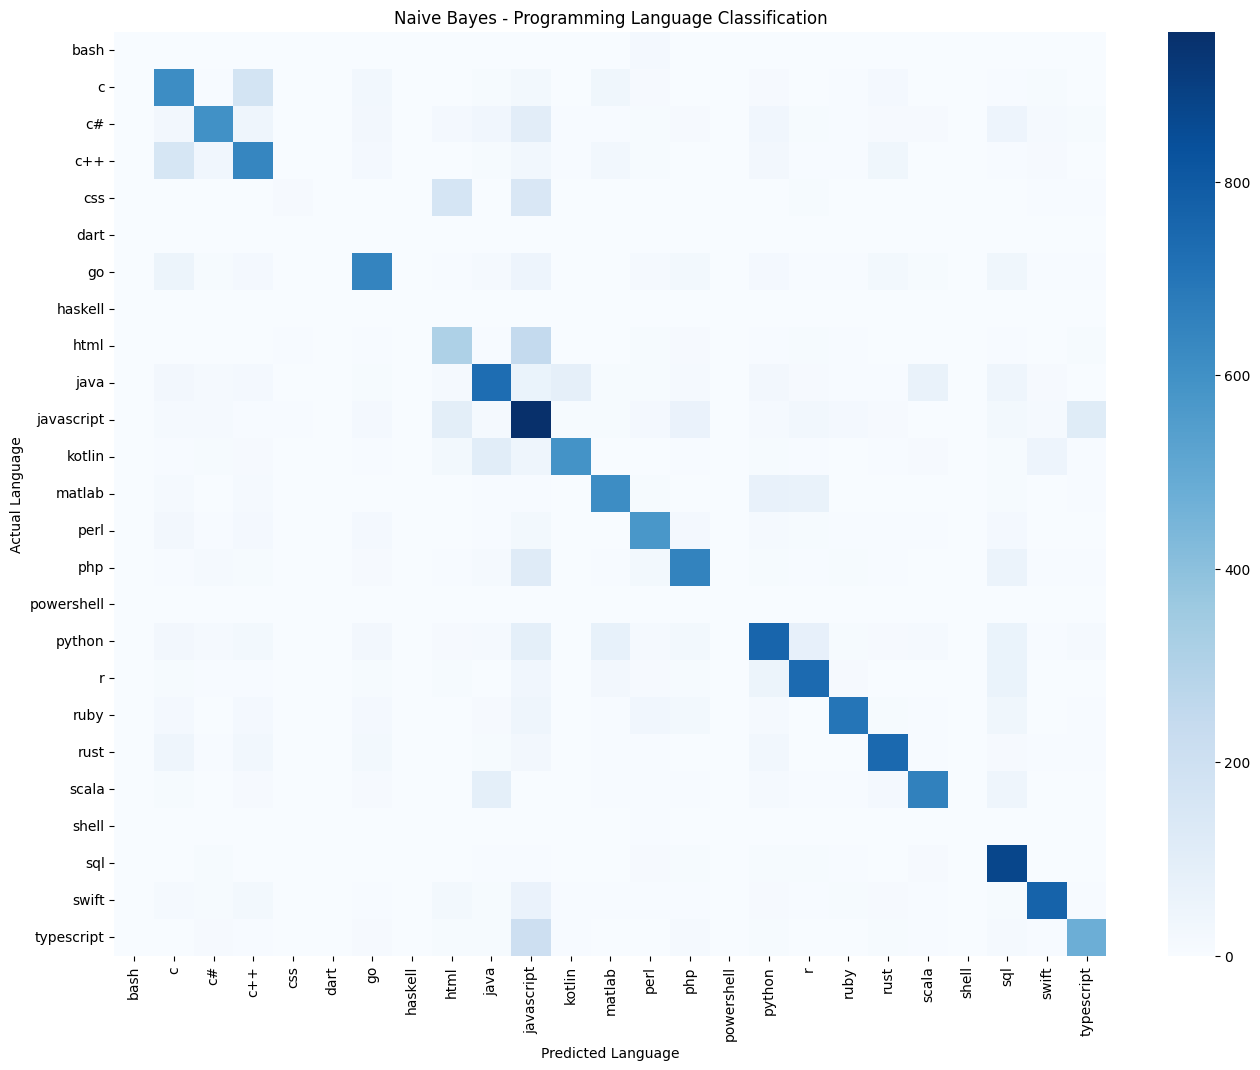

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)

plt.figure(figsize=(16, 12))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.xlabel("Predicted Language")
plt.ylabel("Actual Language")
plt.title("Naive Bayes - Programming Language Classification")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [15]:
# Check class distribution
print("Before filtering:")
print(df_ml['programming_language'].value_counts())

# Keep languages having at least 500 samples
min_samples = 500

valid_languages = (
    df_ml['programming_language']
    .value_counts()
    .loc[lambda x: x >= min_samples]
    .index
)

df_balanced = df_ml[
    df_ml['programming_language'].isin(valid_languages)
].copy()

print("\nAfter filtering:")
print(df_balanced['programming_language'].value_counts())

print("\nNumber of classes:", df_balanced['programming_language'].nunique())
print("Total samples:", len(df_balanced))

Before filtering:
programming_language
javascript    7355
python        6491
java          5948
c++           5272
c#            5167
swift         5044
r             5014
c             4869
rust          4847
ruby          4846
sql           4822
php           4812
go            4811
kotlin        4543
scala         4526
matlab        4157
typescript    4072
perl          3854
html          3200
css           1781
bash           124
shell           48
powershell      22
dart             8
haskell          3
Name: count, dtype: int64

After filtering:
programming_language
javascript    7355
python        6491
java          5948
c++           5272
c#            5167
swift         5044
r             5014
c             4869
rust          4847
ruby          4846
sql           4822
php           4812
go            4811
kotlin        4543
scala         4526
matlab        4157
typescript    4072
perl          3854
html          3200
css           1781
Name: count, dtype: int64

Number of clas

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

# Transform the cleaned text
X = tfidf.fit_transform(df_balanced['clean_text'])

# Target variable
y = df_balanced['programming_language']

print("TF-IDF shape:", X.shape)
print("Number of classes:", y.nunique())

TF-IDF shape: (95431, 10000)
Number of classes: 20


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

Training samples: 76344
Testing samples: 19087

Training feature shape: (76344, 10000)
Testing feature shape: (19087, 10000)

Training class distribution:
programming_language
javascript    5884
python        5193
java          4758
c++           4217
c#            4133
swift         4035
r             4011
c             3895
rust          3877
ruby          3877
sql           3858
php           3850
go            3849
kotlin        3634
scala         3621
matlab        3326
typescript    3258
perl          3083
html          2560
css           1425
Name: count, dtype: int64


In [18]:
from sklearn.naive_bayes import MultinomialNB

# Create Multinomial Naive Bayes model
nb_model_balanced = MultinomialNB()

# Train the model
nb_model_balanced.fit(X_train, y_train)

print("Improved Naive Bayes model trained successfully!")

Improved Naive Bayes model trained successfully!


In [19]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred_balanced = nb_model_balanced.predict(X_test)

# Calculate accuracy
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)

print("Improved Model Accuracy:", accuracy_balanced)
print("Improved Model Accuracy (%):", round(accuracy_balanced * 100, 2), "%")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced,
        zero_division=0
    )
)

Improved Model Accuracy: 0.6607638706973332
Improved Model Accuracy (%): 66.08 %

Classification Report:
              precision    recall  f1-score   support

           c       0.55      0.61      0.58       974
          c#       0.76      0.58      0.66      1034
         c++       0.59      0.62      0.60      1055
         css       0.56      0.03      0.05       356
          go       0.69      0.66      0.68       962
        html       0.43      0.49      0.46       640
        java       0.65      0.62      0.64      1190
  javascript       0.42      0.65      0.51      1471
      kotlin       0.82      0.65      0.72       909
      matlab       0.72      0.75      0.74       831
        perl       0.73      0.74      0.73       771
         php       0.70      0.68      0.69       962
      python       0.65      0.59      0.62      1298
           r       0.73      0.74      0.73      1003
        ruby       0.85      0.71      0.77       969
        rust       0.79      0

In [20]:
from sklearn.naive_bayes import ComplementNB

# Create Complement Naive Bayes model
cnb_model = ComplementNB()

# Train the model
cnb_model.fit(X_train, y_train)

print("Complement Naive Bayes model trained successfully!")

Complement Naive Bayes model trained successfully!


In [21]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred_cnb = cnb_model.predict(X_test)

# Calculate accuracy
cnb_accuracy = accuracy_score(y_test, y_pred_cnb)

print("Complement Naive Bayes Accuracy:", cnb_accuracy)
print("Accuracy (%):", round(cnb_accuracy * 100, 2), "%")

# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_cnb,
        zero_division=0
    )
)

Complement Naive Bayes Accuracy: 0.72389584533976
Accuracy (%): 72.39 %

Classification Report:
              precision    recall  f1-score   support

           c       0.61      0.59      0.60       974
          c#       0.80      0.64      0.71      1034
         c++       0.68      0.62      0.65      1055
         css       0.44      0.15      0.22       356
          go       0.81      0.76      0.78       962
        html       0.42      0.51      0.46       640
        java       0.78      0.65      0.71      1190
  javascript       0.58      0.56      0.57      1471
      kotlin       0.78      0.78      0.78       909
      matlab       0.70      0.85      0.77       831
        perl       0.75      0.88      0.81       771
         php       0.77      0.83      0.80       962
      python       0.87      0.65      0.74      1298
           r       0.74      0.77      0.75      1003
        ruby       0.88      0.85      0.86       969
        rust       0.81      0.86      

In [22]:
import pandas as pd

# Model comparison
results = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes (25 Classes)',
        'Multinomial Naive Bayes (20 Classes)',
        'Complement Naive Bayes (20 Classes)'
    ],
    'Accuracy': [
        accuracy,
        accuracy_balanced,
        cnb_accuracy
    ]
})

# Convert accuracy to percentage
results['Accuracy (%)'] = (results['Accuracy'] * 100).round(2)

print(results)

                                  Model  Accuracy  Accuracy (%)
0  Multinomial Naive Bayes (25 Classes)  0.662275         66.23
1  Multinomial Naive Bayes (20 Classes)  0.660764         66.08
2   Complement Naive Bayes (20 Classes)  0.723896         72.39


In [23]:
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score

# Alpha values to test
alpha_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]

tuning_results = []

for alpha in alpha_values:
    model = ComplementNB(alpha=alpha)

    # Train
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, predictions)

    tuning_results.append({
        'alpha': alpha,
        'accuracy': acc,
        'accuracy_percent': round(acc * 100, 2)
    })

# Display results
tuning_df = pd.DataFrame(tuning_results)

print(tuning_df)

# Best alpha
best_row = tuning_df.loc[tuning_df['accuracy'].idxmax()]

print("\nBest Alpha:", best_row['alpha'])
print("Best Accuracy:", best_row['accuracy_percent'], "%")

   alpha  accuracy  accuracy_percent
0   0.01  0.724158             72.42
1   0.10  0.724105             72.41
2   0.50  0.724001             72.40
3   1.00  0.723896             72.39
4   2.00  0.724891             72.49
5   5.00  0.725939             72.59

Best Alpha: 5.0
Best Accuracy: 72.59 %


In [24]:
from sklearn.naive_bayes import ComplementNB

# Best hyperparameter found during tuning
best_alpha = 5.0

# Create final Complement Naive Bayes model
final_model = ComplementNB(alpha=best_alpha)

# Train on the training data
final_model.fit(X_train, y_train)

print("Final model trained successfully!")
print("Algorithm: Complement Naive Bayes")
print("Alpha:", best_alpha)

Final model trained successfully!
Algorithm: Complement Naive Bayes
Alpha: 5.0


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predict on the test set
y_pred_final = final_model.predict(X_test)

# Calculate metrics
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted', zero_division=0)
recall_final = recall_score(y_test, y_pred_final, average='weighted', zero_division=0)
f1_final = f1_score(y_test, y_pred_final, average='weighted', zero_division=0)

print("===== FINAL MODEL RESULTS =====")
print(f"Accuracy  : {accuracy_final:.4f} ({accuracy_final * 100:.2f}%)")
print(f"Precision : {precision_final:.4f}")
print(f"Recall    : {recall_final:.4f}")
print(f"F1-Score  : {f1_final:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_test,
    y_pred_final,
    zero_division=0
))

===== FINAL MODEL RESULTS =====
Accuracy  : 0.7259 (72.59%)
Precision : 0.7324
Recall    : 0.7259
F1-Score  : 0.7225

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           c       0.62      0.59      0.60       974
          c#       0.80      0.64      0.71      1034
         c++       0.68      0.62      0.65      1055
         css       0.47      0.15      0.23       356
          go       0.80      0.77      0.78       962
        html       0.41      0.51      0.46       640
        java       0.79      0.65      0.71      1190
  javascript       0.57      0.56      0.57      1471
      kotlin       0.79      0.79      0.79       909
      matlab       0.70      0.86      0.77       831
        perl       0.76      0.89      0.82       771
         php       0.77      0.83      0.80       962
      python       0.88      0.65      0.75      1298
           r       0.75      0.76      0.76      1003
        ruby       0.89      0.85    

<Figure size 1400x1200 with 0 Axes>

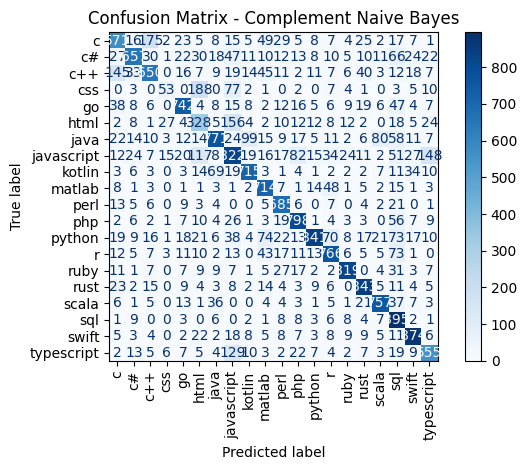

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_final, labels=final_model.classes_)

# Plot
plt.figure(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_model.classes_
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Complement Naive Bayes")
plt.tight_layout()
plt.show()

In [33]:
# Function to predict programming language from new user input

def predict_language(question):
    # Apply the same preprocessing used during training
    cleaned_question = preprocess_text(question)

    # Convert text into TF-IDF features
    question_tfidf = tfidf.transform([cleaned_question])

    # Predict programming language
    prediction = final_model.predict(question_tfidf)[0]

    return prediction


# Take input from user
user_input = input("Enter your programming-related question: ")

# Predict
predicted_language = predict_language(user_input)

# Display result
print("\n==============================")
print("Input Question:", user_input)
print("Predicted Programming Language:", predicted_language)
print("==============================")

Enter your programming-related question: js and python

Input Question: js and python
Predicted Programming Language: python
